In [1]:
import csv
import sys
import random
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

import distanceclosure as dc
from distanceclosure.dijkstra import single_source_dijkstra_path_length

In [2]:
add_probability = 1.0

input_dir = Path("sampled/")

MANUAL_FIXES = [('FOXP3', 'TGFB')]


In [3]:
def get_U_from_file(input_file):
    df = pd.read_csv(input_file)

    U = nx.DiGraph()

    weighted_edges = df[
        ["Regulator", "Target", "Confidence Rank"]
    ].itertuples(index=False, name=None)

    U.add_weighted_edges_from(weighted_edges, weight="distance")

    print(f"U: {U.number_of_nodes()} nodes, {U.number_of_edges()} edges")

    return U

In [4]:
def get_G_from_U(U, add_probability):
    regulators = set(U.nodes())

    excluded_targets = {
        "IKB", "IL7R", "CD28", "TCR", "NOTCH1",
        "IFNAR", "IFNBR", "IL15R", "IL27R", "IL29R", "IL36R"
    }

    # Source nodes cannot be targets
    source_nodes = {
        node for node in U.nodes()
        if U.in_degree(node) == 0
    }

    targets = set(U.nodes()) - excluded_targets - source_nodes

    n_possible = len(regulators) * len(targets)
    n_existing = U.number_of_edges()

    print(f"Number of regulators: {len(regulators)}")
    print(f"Number of targets: {len(targets)}")
    print(f"Possible regulator-target pairs: {n_possible}")
    print(f"Existing regulator-target pairs: {n_existing}")

    existing_pairs = set(U.edges())

    G = U.copy()

    new_edges = []

    for regulator in regulators:
        for target in targets:
            if (regulator, target) not in existing_pairs:
                if random.random() <= add_probability:
                    new_edges.append((regulator, target, 6))

    G.add_weighted_edges_from(new_edges, weight="distance")

    print(f"Created {len(new_edges)} fake edges.")
    print(f"G: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    return G

In [5]:
def print_report(graph):
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    print(f"Number of self-loops: {len([e for e in graph.edges() if e[0] == e[1]])}")
    max_in_degree = 0
    max_in_degree_node = None
    log2_number_of_possible_BN = 1
    for node in graph.nodes():
        log2_number_of_possible_BN += 2**graph.in_degree(node)

        if graph.in_degree(node) > max_in_degree:
            max_in_degree = graph.in_degree(node)
            max_in_degree_node = node
    print("node with highest in-degree: ", max_in_degree_node, " with in-degree: ", max_in_degree)
    print("number of possible Boolean Networks: 2^", log2_number_of_possible_BN)

In [6]:
# --- Helper to process bottleneck cycles per graph ---
def get_bottleneck_cycles(graph, target_nodes):
    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    results = {}
    
    for node in target_nodes:
        if node not in graph:
            continue
        results[node] = {}
        
        # 1. Capture standalone self-loops directly
        if graph.has_edge(node, node):
            results[node][node] = ((node, node), graph[node][node].get('distance'))
            
        # 2. Use your Dijkstra function to find the minimax return path from successors
        for neighbor in graph.successors(node):
            if neighbor == node:
                continue
                
            paths = {neighbor: [neighbor]}
            weight_fn = lambda v, u, e: e.get('distance')
            
            try:
                # Find the path that minimizes the maximum edge weight back to 'node'
                dist = single_source_dijkstra_path_length(
                    graph, 
                    source=neighbor, 
                    weight_function=weight_fn, 
                    paths=paths, 
                    disjunction=max
                )
                
                # If the target node was reached, a valid optimal bottleneck cycle exists
                if node in dist:
                    path_back = paths[node]
                    full_cycle = [node] + path_back
                    
                    # Total bottleneck is the max of the exit edge and the path back
                    exit_edge_w = graph[node][neighbor].get('distance')
                    cycle_max_w = max(exit_edge_w, dist[node])
                    
                    results[node][neighbor] = (tuple(full_cycle), cycle_max_w)
            except (nx.NodeNotFound, ValueError):
                continue
                
    return results

In [7]:
def check_cycles(cycles_G, cycles_B):
    errors = []

    for node in set(cycles_G) | set(cycles_B):
        g_routes = cycles_G.get(node, {})
        b_routes = cycles_B.get(node, {})

        # 1. Every cycle in B must also exist in G with the same weight
        for neighbor, (b_path, b_weight) in b_routes.items():
            g_route = g_routes.get(neighbor)

            if g_route is None:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' "
                    f"exists in B but is missing in G."
                )
                continue

            g_path, g_weight = g_route

            if g_weight != b_weight:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' has "
                    f"different weights: G={g_weight}, B={b_weight}."
                )

        # 2. Global minimum cycle weight must agree
        if g_routes and b_routes:
            min_weight_G = min(w for path, w in g_routes.values())
            min_weight_B = min(w for path, w in b_routes.values())

            if min_weight_G != min_weight_B:
                errors.append(
                    f"Node '{node}': minimum cycle weight differs: "
                    f"G={min_weight_G}, B={min_weight_B}."
                )

        elif g_routes and not b_routes:
            errors.append(
                f"Node '{node}': G has cycles but B has none."
            )

    return errors

In [8]:
def find_self_edges_to_restore(G, B, cycles_G):
    self_edges_to_restore = []

    for node in G.nodes:
        if not G.has_edge(node, node):
            continue

        if B.has_edge(node, node):
            continue

        g_routes = cycles_G.get(node, {})
        if not g_routes:
            continue

        min_weight_G = min(weight for path, weight in g_routes.values())
        self_weight_G = G[node][node].get("distance")

        if self_weight_G == min_weight_G:
            self_edges_to_restore.append(
                (node, node, G[node][node])
            )
            print(f"Found self-edge to restore: {node}, weight: {self_weight_G}")

    return self_edges_to_restore

In [9]:
results = {}

for file in sorted(input_dir.glob("*.csv")):
    print(f"\nProcessing {file.name}")

    U = get_U_from_file(file)

    print_report(U)

    results[file.stem] = {
        "file": file,
        "U": U,
    }

print(f"\nProcessed {len(results)} files.")


Processing random_kept_01.csv
U: 106 nodes, 297 edges
Number of nodes: 106
Number of edges: 297
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 35912

Processing random_kept_02.csv
U: 106 nodes, 297 edges
Number of nodes: 106
Number of edges: 297
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31842

Processing random_kept_03.csv
U: 106 nodes, 297 edges
Number of nodes: 106
Number of edges: 297
Number of self-loops: 6
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 31722

Processing random_kept_04.csv
U: 106 nodes, 297 edges
Number of nodes: 106
Number of edges: 297
Number of self-loops: 5
node with highest in-degree:  IFNG_2  with in-degree:  14
number of possible Boolean Networks: 2^ 32184

Processing random_kept_05.csv
U: 106 nodes, 297 edges
Number of nodes: 106
Number of edges: 297
Num

In [10]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    U = result["U"]

    G = get_G_from_U(U, add_probability=add_probability)

    result["G"] = G

    print_report(G)


Processing random_kept_01
Number of regulators: 106
Number of targets: 72
Possible regulator-target pairs: 7632
Existing regulator-target pairs: 297
Created 7348 fake edges.
G: 106 nodes, 7645 edges
Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Processing random_kept_02
Number of regulators: 106
Number of targets: 72
Possible regulator-target pairs: 7632
Existing regulator-target pairs: 297
Created 7348 fake edges.
G: 106 nodes, 7645 edges
Number of nodes: 106
Number of edges: 7645
Number of self-loops: 72
node with highest in-degree:  BCL6  with in-degree:  106
number of possible Boolean Networks: 2^ 5841333965851681082096808370372658

Processing random_kept_03
Number of regulators: 106
Number of targets: 72
Possible regulator-target pairs: 7632
Existing regulator-target pairs: 297
Created 7348 fake edges.
G: 106 nodes, 7645 edges


In [11]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]

    B = dc.ultrametric_backbone(G, weight='distance', self_loops=False)
    result["B"] = B

    print_report(B)


Processing random_kept_01
Number of nodes: 106
Number of edges: 788
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 4027186

Processing random_kept_02
Number of nodes: 106
Number of edges: 788
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 3776690

Processing random_kept_03
Number of nodes: 106
Number of edges: 786
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 3758770

Processing random_kept_04
Number of nodes: 106
Number of edges: 646
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  19
number of possible Boolean Networks: 2^ 955666

Processing random_kept_05
Number of nodes: 106
Number of edges: 786
Number of self-loops: 0
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 4030770

Proce

In [12]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]

    B = result["B"]
    
    target_nodes = [
        n for n in set(list(G.nodes()) + list(B.nodes()))
        if G.has_edge(n, n) or B.has_edge(n, n)
    ]

    print(f"{len(target_nodes)} target nodes:", target_nodes)

    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    cycles_G = get_bottleneck_cycles(G, target_nodes)
    cycles_B = get_bottleneck_cycles(B, target_nodes)

    result["cycles_G"] = cycles_G
    result["cycles_B"] = cycles_B

    errors = check_cycles(cycles_G, cycles_B)

    if errors:
        print("Cycle check failed:")
        for error in errors:
            print(" -", error)
    else:
        print("Cycle check passed.")



Processing random_kept_01
72 target nodes: ['TBET', 'IL2', 'IL4R_2', 'IFNGR_2', 'RORGT', 'GATA3', 'IL31', 'IL5', 'TGFB', 'STAT3', 'STAT5', 'IFNG', 'IL24', 'IL12R', 'IL1R', 'IL4RA_2', 'NFAT', 'IL2R_2', 'SMAD3', 'IL2R', 'IL21R', 'IL12RB1_2', 'IL10R', 'IFNGR', 'IL4R', 'THPOK', 'IL23R', 'IL6R', 'STAT6', 'PU1', 'JAK1', 'IRAK', 'RUNX3', 'IL12RB2', 'SMAD2', 'BCL6', 'IRF1', 'IL25R', 'FOXP3', 'SOCS1', 'CMAF', 'IL22', 'IL13', 'GZMB', 'STAT5_2', 'STAT4', 'IL33R', 'TGFBR', 'IL2RA', 'CD4', 'EOMES', 'IFNG_2', 'IL21', 'IL18R', 'IL10', 'TBET_2', 'IL1R1', 'IL4', 'NFKB', 'proliferation', 'STAT1', 'IL6', 'CD8', 'IL17', 'IL23', 'IL3', 'STAT1_2', 'IL25', 'ST2', 'IL9', 'PRF1', 'IL35']
Cycle check passed.

Processing random_kept_02
72 target nodes: ['TBET', 'IL2', 'IL4R_2', 'IFNGR_2', 'RORGT', 'GATA3', 'IL31', 'IL5', 'TGFB', 'STAT3', 'STAT5', 'IFNG', 'IL24', 'IL12R', 'IL1R', 'IL4RA_2', 'NFAT', 'IL2R_2', 'SMAD3', 'IL2R', 'IL21R', 'IL12RB1_2', 'IL10R', 'IFNGR', 'IL4R', 'THPOK', 'IL23R', 'IL6R', 'STAT6', 'PU1'

In [13]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]
    B = result["B"]
    cycles_G = result["cycles_G"]

    self_edges_to_restore = find_self_edges_to_restore(
        G, B, cycles_G
    )

    B2 = B.copy()
    B2.add_edges_from(self_edges_to_restore)

    cycles_B2 = get_bottleneck_cycles(B2, target_nodes)

    errors = check_cycles(cycles_G, cycles_B2)

    if errors:
        print("Cycle check failed:")
        for error in errors:
            print(" -", error)
    else:
        print("Cycle check passed.")

    self_edges_to_restore = find_self_edges_to_restore(
        G, B2, cycles_G
    )

    if self_edges_to_restore:
        print(f"Found {len(self_edges_to_restore)} self-edges to restore.")
    else:
        print("No self-edges to restore.")

    print_report(B2)

    result["B2"] = B2
    result["cycles_B2"] = cycles_B2


Processing random_kept_01
Found self-edge to restore: GATA3, weight: 1
Found self-edge to restore: THPOK, weight: 1
Found self-edge to restore: IL22, weight: 6
Found self-edge to restore: GZMB, weight: 6
Found self-edge to restore: PRF1, weight: 6
Found self-edge to restore: IL35, weight: 6
Found self-edge to restore: RORGT, weight: 1
Found self-edge to restore: IL13, weight: 6
Found self-edge to restore: STAT1, weight: 1
Found self-edge to restore: IL17, weight: 6
Found self-edge to restore: IL31, weight: 6
Found self-edge to restore: proliferation, weight: 4
Cycle check passed.
No self-edges to restore.
Number of nodes: 106
Number of edges: 800
Number of self-loops: 12
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 4589874

Processing random_kept_02
Found self-edge to restore: GATA3, weight: 1
Found self-edge to restore: THPOK, weight: 1
Found self-edge to restore: IL22, weight: 6
Found self-edge to restore: GZMB, weight: 6
Found se

In [14]:
for name, result in results.items():
    print(f"\nProcessing {name}")
    G = result["G"]
    B = result["B"]
    B2 = result["B2"]

    B3 = B2.copy()
    if MANUAL_FIXES:
        print(f"Adding {len(MANUAL_FIXES)} edges back into Graph B...")

        edges_to_add = []
        for edge in MANUAL_FIXES:
            u, v = edge
            edges_to_add.append((u, v, G[u][v]))

        B3.add_edges_from(edges_to_add)
        
        # Recalculate bottleneck paths for B now that it has been altered
        cycles_B_updated = get_bottleneck_cycles(B3, target_nodes)
    else:
        print("No target nodes triggered the condition. Graph B remains unchanged.")

    print_report(B3)

    result["B3"] = B3


Processing random_kept_01
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 801
Number of self-loops: 12
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 4590386

Processing random_kept_02
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 801
Number of self-loops: 12
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 4069426

Processing random_kept_03
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 800
Number of self-loops: 13
node with highest in-degree:  IFNG_2  with in-degree:  21
number of possible Boolean Networks: 2^ 4052018

Processing random_kept_04
Adding 1 edges back into Graph B...
Number of nodes: 106
Number of edges: 657
Number of self-loops: 10
node with highest in-degree:  IFNG_2  with in-degree:  19
number of possible Boolean Networks: 2^ 1028338

Processing random_kept_05
Adding 1 edges back into Grap

In [15]:
import matplotlib.pyplot as plt
import pandas as pd


def get_pct_reduced(result):
    """
    Calculate the percentage of fake edges removed.

    Adjust the graph keys here to match your results structure.
    """
    U = result["U"]
    G = result["G"]
    B = result["B"]

    original = U.number_of_edges()
    reduced = G.number_of_edges() - B.number_of_edges()

    fake_edges = G.number_of_edges() - original

    if fake_edges == 0:
        return 0

    return 100 * reduced / fake_edges


def plot_reduction_results(results):
    kept = []
    taken_out = []
    selected = []

    for name, result in results.items():
        pct = get_pct_reduced(result)

        if name.startswith("random_kept_"):
            kept.append(pct)
        elif name.startswith("random_taken_out_"):
            taken_out.append(pct)
        elif name.startswith("selected_nodes_"):
            selected.append(pct)

    data = pd.DataFrame({
        "Random KEPT": kept,
        "Random TAKEN_OUT": taken_out,
        "Selected nodes": selected
    })

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.boxplot(
        [kept, taken_out, selected],
        labels=["Random KEPT", "Random TAKEN_OUT", "Selected nodes"],
    )

    ax.set_ylabel("Percentage of fake edges reduced (%)")
    ax.set_title("Reduction of Fake Edges")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    ax.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_93749/1551723679.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_93749/1551723679.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


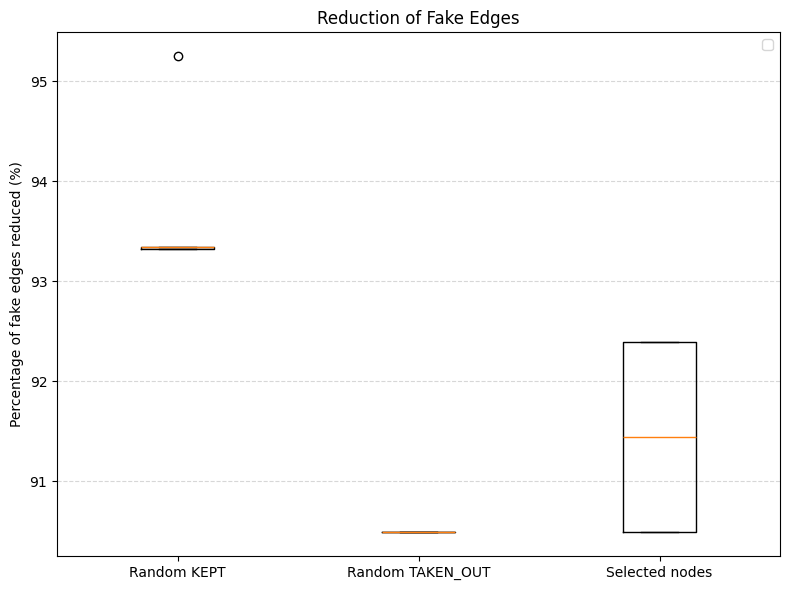

In [16]:
plot_reduction_results(results)